In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
plt.rcParams['figure.figsize'] = (14,6)

In [2]:
df = pd.read_csv("C:\\Users\\ankit\\Downloads\\train.csv (1)\\train.csv", parse_dates=['date'])
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [6]:
df.shape

(3000888, 6)

In [7]:
df.describe()

,id,date,store_nbr,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088384,2.750000e+01,3.577757e+02,2.602770e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01


In [8]:
# Examine Date Range
print("Date Range Information")
print(f"Start Date: {df['date'].min()}")
print(f"End Date: {df['date'].max()}")

time_span = df['date'].max() - df['date'].min()
print(f"Time Span: {time_span.days}days ({time_span.days/365:.1f}years)")

Date Range Information
Start Date: 2013-01-01 00:00:00
End Date: 2017-08-15 00:00:00
Time Span: 1687days (4.6years)


In [9]:
# Aggregate data by date
daily_sales = df.groupby('date')['sales'].sum().reset_index()

daily_sales.columns = ['date','total_sales']

daily_sales = daily_sales.sort_values('date').reset_index(drop=True)

print(f"Daily aggregated records: {len(daily_sales)}")
daily_sales.head(10)

Daily aggregated records: 1684


,date,total_sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229
5,2013-01-06,519695.401088
6,2013-01-07,336122.801066
7,2013-01-08,318347.777981
8,2013-01-09,302530.809018
9,2013-01-10,258982.003049


In [10]:
ts_data = daily_sales.copy()
ts_data.set_index("date", inplace=True)
ts_data.head()

,total_sales
date,
2013-01-01,2511.618999
2013-01-02,496092.417944
2013-01-03,361461.231124
2013-01-04,354459.677093
2013-01-05,477350.121229


In [11]:
ts_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1684 entries, 2013-01-01 to 2017-08-15
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   total_sales  1684 non-null   float64
dtypes: float64(1)
memory usage: 26.3 KB


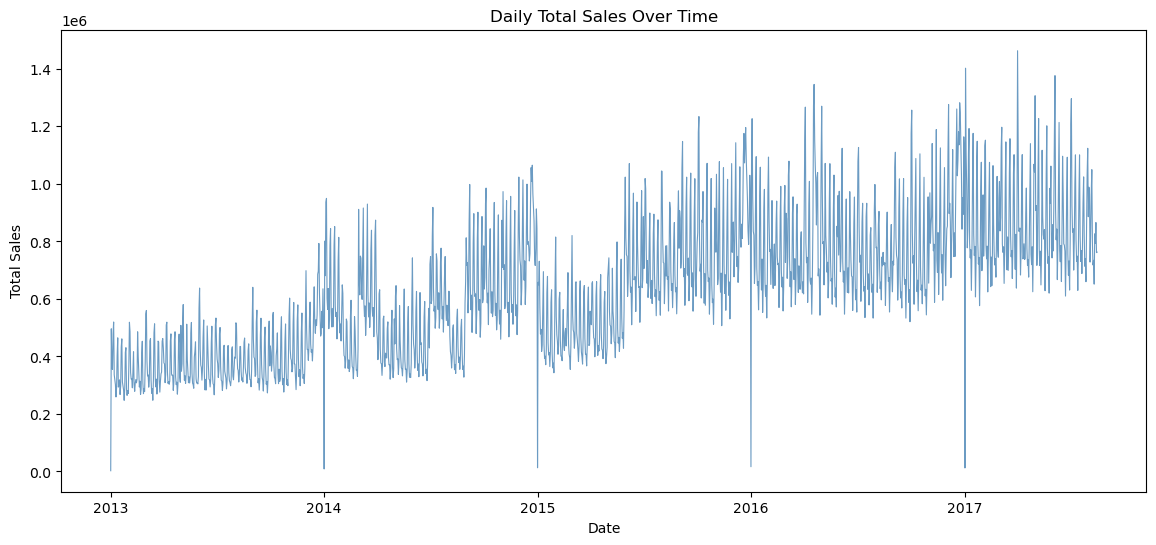

In [12]:
plt.figure(figsize=(14,6))
plt.plot(ts_data.index, ts_data['total_sales'], color='steelblue', linewidth=0.8, alpha=0.8)
plt.title('Daily Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

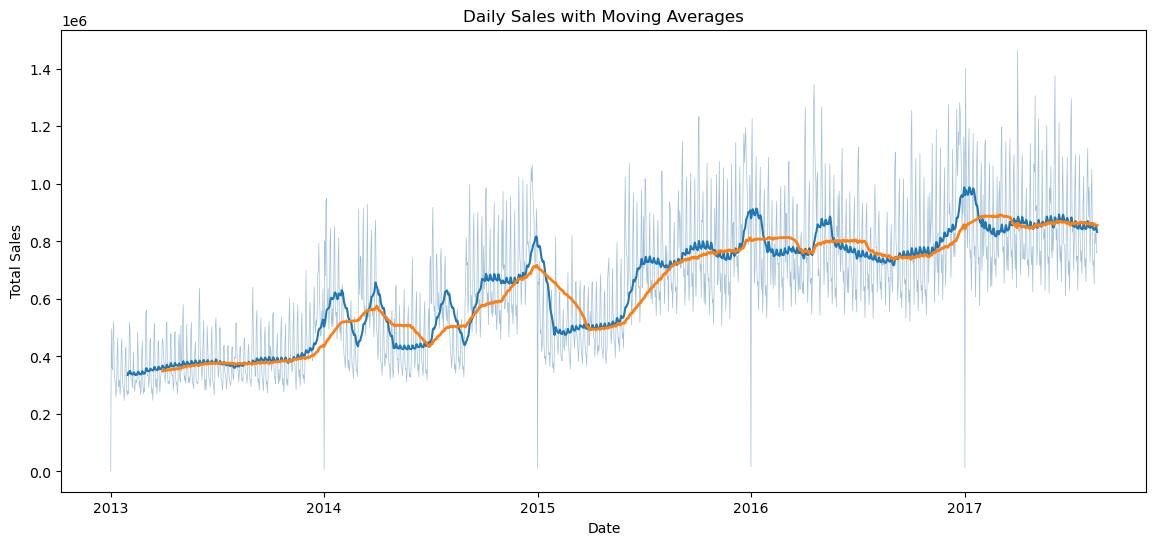

In [15]:
# Add Moving Average to Reveal Trend
ts_data['MA_30'] = ts_data['total_sales'].rolling(window=30).mean()
ts_data['MA_90'] = ts_data['total_sales'].rolling(window=90).mean()

plt.plot(ts_data.index, ts_data['total_sales'], color='steelblue', linewidth=0.5, alpha=0.5, label='Daily Sales')
plt.plot(ts_data.index, ts_data['MA_30'], color='darkorange', linewidth=1.5, label='30 Day Moving Average')
plt.plot(ts_data.index, ts_data['MA_90'], color='crimson', linewidth=2.0, label='90 Day Moving Average')
plt.legend(loc='upper left')
plt.title('Daily Sales with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

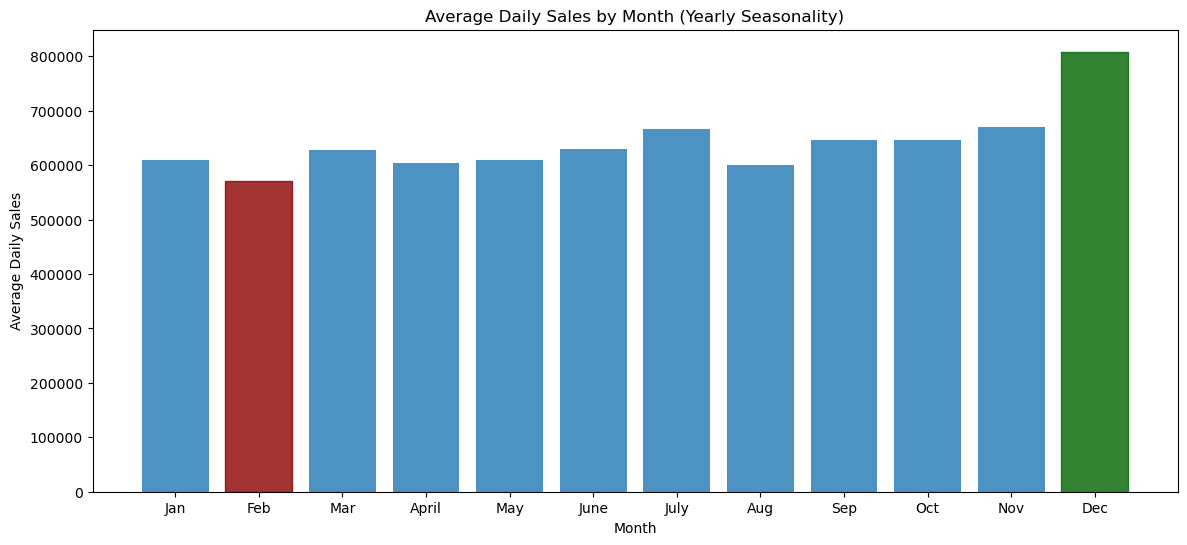

In [14]:
# Analyze Monthly Patterns (Seasonality)

# Create monthly column from index
monthly_pattern = ts_data.copy()
monthly_pattern['month'] = monthly_pattern.index.month

# 
monthly_avg = monthly_pattern.groupby('month')['total_sales'].mean()

month_names = ['Jan','Feb','Mar','April','May','June',
              'July','Aug','Sep','Oct','Nov','Dec']

bars = plt.bar(range(1,13), monthly_avg.values, alpha=0.8)
# Highlight highest and lowest months
max_month = monthly_avg.idxmax()
min_month = monthly_avg.idxmin()
bars[max_month-1].set_color('darkgreen')
bars[min_month-1].set_color('darkred')
plt.title('Average Daily Sales by Month (Yearly Seasonality)')
plt.xlabel('Month')
plt.ylabel('Average Daily Sales')
plt.xticks(range(1,13), month_names)
plt.show()

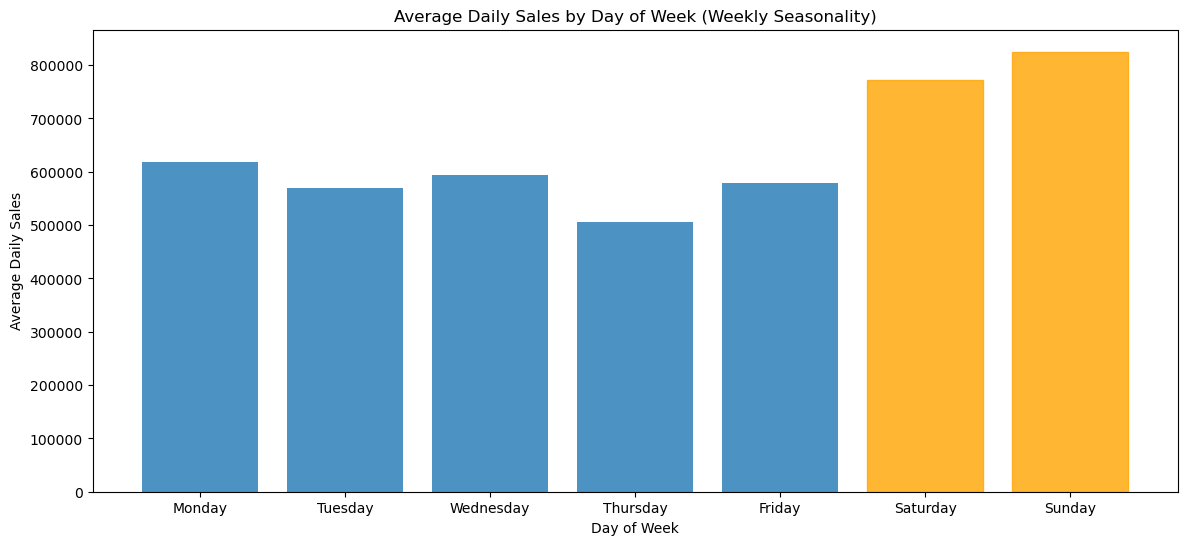

In [15]:
# Analyze Day of week patterns (Weekly Seasonality)
weekly_pattern = ts_data.copy()
weekly_pattern['day_of_week'] = weekly_pattern.index.dayofweek

# Caluclate average sales by day of week
weekly_avg = weekly_pattern.groupby('day_of_week')['total_sales'].mean()

day_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

bars = plt.bar(range(7), weekly_avg.values, alpha=0.8)
# Highlight highest and lowest months

bars[5].set_color('orange')
bars[6].set_color('orange')
plt.title('Average Daily Sales by Day of Week (Weekly Seasonality)')
plt.xlabel('Day of Week')
plt.ylabel('Average Daily Sales')
plt.xticks(range(7), day_names)
plt.show()

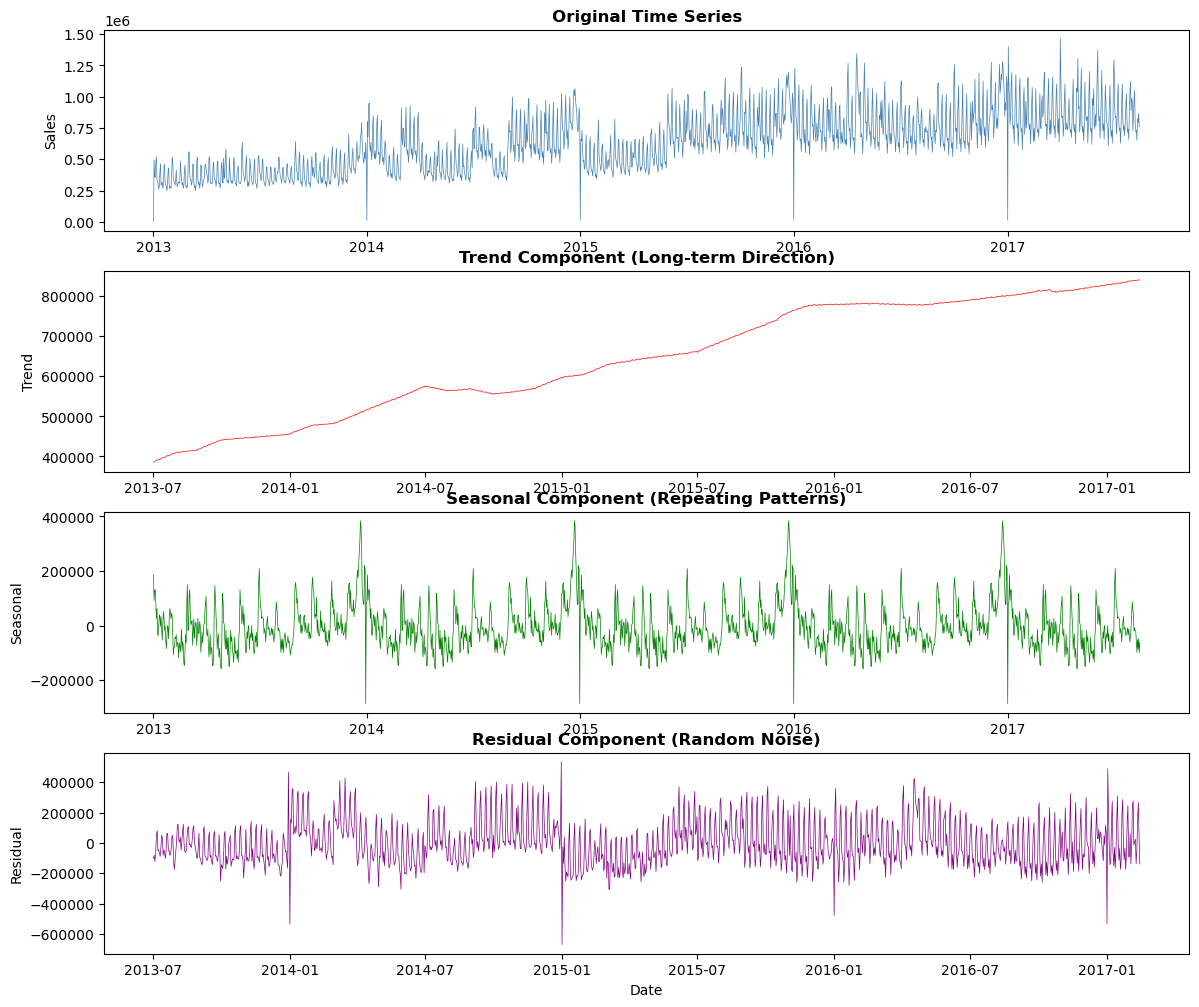

In [21]:
# Perform Time-Series Decomposition
decomposition = seasonal_decompose(ts_data['total_sales'], model='additive', period=365)

# Create a 4 panel plot showing all components
fig, axes = plt.subplots(4, 1, figsize=(14,12))

# Panel 1: Original Data
axes[0].plot(ts_data.index, ts_data['total_sales'], color='steelblue', linewidth=0.5)
axes[0].set_title('Original Time Series', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sales')

# Panel 2: Trend Component
axes[1].plot(decomposition.trend.index, decomposition.trend, color='red', linewidth=0.5)
axes[1].set_title('Trend Component (Long-term Direction)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Trend')

# Panel 3: Seasonal Component
axes[2].plot(decomposition.seasonal.index, decomposition.seasonal, color='green', linewidth=0.5)
axes[2].set_title('Seasonal Component (Repeating Patterns)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonal')

# Panel 3: Residual (Noise)
axes[3].plot(decomposition.resid.index, decomposition.resid, color='purple', linewidth=0.5)
axes[3].set_title('Residual Component (Random Noise)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
plt.show()

In [29]:
# Quantify the Components
# Original data statistics
original_std = ts_data['total_sales'].std()
print(f"Original Series Std Dev: {original_std:.2f}")
# Trend statistics
trend_std = decomposition.trend.dropna().std()
print(f"Trend Std Dev: {trend_std:.2f}")
# Seasonal statistics
seasonal_std = decomposition.trend.dropna().std()
print(f"Seasonal Std Dev: {seasonal_std:.2f}")
# Residual statistics
residual_std = decomposition.resid.dropna().std()
print(f"Residual Std Dev: {residual_std:.2f}")

# Calculate percentage contribution of each component
total_variation = trend_std + seasonal_std + residual_std
print(f"\n--- Relative Importance ---")
print(f"Trend contribution: {(trend_std/total_variation)*100:.1f}%")
print(f"Seasonal contribution: {(seasonal_std/total_variation)*100:.1f}%")
print(f"Residual (noise) contribution: {(residual_std/total_variation)*100:.1f}%")

Original Series Std Dev: 234410.24
Trend Std Dev: 136802.14
Seasonal Std Dev: 136802.14
Residual Std Dev: 146318.53

--- Relative Importance ---
Trend contribution: 32.6%
Seasonal contribution: 32.6%
Residual (noise) contribution: 34.8%
